# Customer sentiment analysis

---

## 1. Install and Import python libraries
- This section handles data, preprocessing steps, modelling and evaluation


In [1]:
!pip install -q requests nltk

import pandas as pd
import numpy as np
import re
import zipfile
import requests
import matplotlib.pyplot as plt

from io import BytesIO

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


## 2. Download and load 2 real datasets
- This section focuses on loading the 2 datasets: Amazon and Yelp customer reviews

In [2]:
zip_url = "https://archive.ics.uci.edu/static/public/331/sentiment%2Blabelled%2Bsentences.zip"
response = requests.get(zip_url)
response.raise_for_status()

z = zipfile.ZipFile(BytesIO(response.content))

files = {
    "amazon": "sentiment labelled sentences/amazon_cells_labelled.txt",
    "yelp": "sentiment labelled sentences/yelp_labelled.txt"
}

dfs = []

for source, file_path in files.items():
    df_part = pd.read_csv(
        z.open(file_path),
        sep="\t",
        header=None,
        names=["text", "label"]
    )
    df_part["source"] = source
    dfs.append(df_part)

df = pd.concat(dfs, ignore_index=True)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2000, 3)


,text,label,source
0,So there is no way for me to plug it in here i...,0,amazon
1,"Good case, Excellent value.",1,amazon
2,Great for the jawbone.,1,amazon
3,Tied to charger for conversations lasting more...,0,amazon
4,The mic is great.,1,amazon


## 3. Checking the dataset
- This section focuses on esnuring the dataset has been correctly loaded: In terms of columns and rows and checks label balance

In [3]:
print("Label counts:")
print(df["label"].value_counts())
print()

print("Source counts:")
print(df["source"].value_counts())
print()

print("Sample rows:")
print(df.sample(10, random_state=42))

Label counts:
label
0    1000
1    1000
Name: count, dtype: int64

Source counts:
source
amazon    1000
yelp      1000
Name: count, dtype: int64

Sample rows:
                                                   text  label  source
1860  This place is pretty good, nice little vibe in...      1    yelp
353   Their network coverage in Los Angeles is horri...      0  amazon
1333                              Everything was gross.      0    yelp
905   Not nearly as good looking as the AMAZON pictu...      0  amazon
1289  I hate to disagree with my fellow Yelpers, but...      0    yelp
1273  Stopped by this place while in Madison for the...      1    yelp
938                Logitech Bluetooth Headset is a 10!.      1  amazon
1731  Ryan's Bar is definitely one Edinburgh establi...      0    yelp
65    The one big drawback of the MP3 player is that...      0  amazon
1323  A couple of months later, I returned and had a...      1    yelp


## 4. Preprocessing the data
- This section cleans the data by removing lowercases, punctionation, numbers and removing short words

In [4]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()
    words = [word for word in words if len(word) > 2]
    return " ".join(words)

df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text", "label"]].head(10)

,text,clean_text,label
0,So there is no way for me to plug it in here i...,there way for plug here the unless converter,0
1,"Good case, Excellent value.",good case excellent value,1
2,Great for the jawbone.,great for the jawbone,1
3,Tied to charger for conversations lasting more...,tied charger for conversations lasting more th...,0
4,The mic is great.,the mic great,1
5,I have to jiggle the plug to get it to line up...,have jiggle the plug get line right get decent...,0
6,If you have several dozen or several hundred c...,you have several dozen several hundred contact...,0
7,If you are Razr owner...you must have this!,you are razr owner you must have this,1
8,"Needless to say, I wasted my money.",needless say wasted money,0
9,What a waste of money and time!.,what waste money and time,0


## 5. Split data & Tokenise text
- In this section the data is split into 80% training and 20% testing, as well as tokenised using TF-IDF to represent word importance

In [5]:
if 'clean_text' not in df.columns:

    def clean_text(text):
        text = str(text).lower()
        text = handle_negation(text)
        text = re.sub(r"[^a-z\s_]", " ", text)
        words = text.split()
        words = [word for word in words if len(word) > 2]
        return " ".join(words)

    df["clean_text"] = df["text"].apply(clean_text)

X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


#Tokenise text
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 1)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training feature shape:", X_train_tfidf.shape)
print("Testing feature shape:", X_test_tfidf.shape)

Training samples: 1600
Testing samples: 400
Training feature shape: (1600, 2717)
Testing feature shape: (400, 2717)


##6. Train on Linear SVM
- This section trains the data on the model  **Linear SVM**

In [6]:
models = {
    "Linear SVM": LinearSVC(C=1)
}

for model_name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    print(f"{model_name} trained successfully.")

best_model = models["Linear SVM"]


Linear SVM trained successfully.


##7. Implement Linear SVM
- This section evauates the Linear SVM model using accuracy, precision, recall, F1- Score and confusion matrix

        Model  Accuracy  Precision  Recall  F1-score
0  Linear SVM     0.845   0.841584    0.85  0.845771


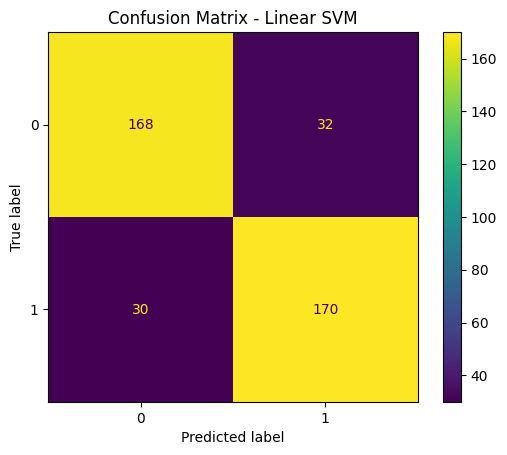

In [7]:
y_pred = best_model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

metrics_df = pd.DataFrame([{
    "Model": "Linear SVM",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
}])

print(metrics_df)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix - Linear SVM")
plt.show()

## 8. Test model on new customer reviews

In [8]:
# Test the best model on new example customer reviews
sample_reviews = [
    "The product was amazing and delivery was fast",
    "Terrible service, I want a refund",
    "The food was fresh and tasted great",
    "I am very disappointed with the quality",
    "Customer support was helpful and solved my issue quickly",
    "The food was ok, could've been better",
    "Loved the customer service, will be coming back",
    "not good"
]

clean_reviews = [clean_text(r) for r in sample_reviews]
features = vectorizer.transform(clean_reviews)

predictions = best_model.predict(features)

sentiments = ["Positive" if p == 1 else "Negative" for p in predictions]

results_df = pd.DataFrame({
    "Review": sample_reviews,
    "Predicted Sentiment": sentiments
})

print(results_df)

                                              Review Predicted Sentiment
0      The product was amazing and delivery was fast            Positive
1                  Terrible service, I want a refund            Negative
2                The food was fresh and tasted great            Positive
3            I am very disappointed with the quality            Negative
4  Customer support was helpful and solved my iss...            Positive
5              The food was ok, could've been better            Negative
6    Loved the customer service, will be coming back            Positive
7                                           not good            Negative
